<a href="https://colab.research.google.com/github/Preenon-ngs/Preenon-ngs/blob/main/human_gut_microbiome_python_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pgmpy

In [ ]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch, BicScore
from pgmpy.models import BayesianNetwork
from pgmpy.inference import VariableElimination
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
# Load the data
meta_data = pd.read_csv("meta.csv")
taxtable_data = pd.read_csv("taxtable.csv")

# Merge metadata with taxonomic table
data = pd.merge(meta_data, taxtable_data, left_on="Unnamed: 0", right_on="Unnamed: 0")

In [ ]:
# Convert categorical variables to strings for Bayesian modeling
data["Birthmode"] = data["Birthmode"].astype(str)
data["Breastmilk"] = data["Breastmilk"].astype(str)
data["Antibiotic"] = data["Antibiotic"].astype(str)

In [ ]:
# Select relevant columns (metadata and top taxa for simplicity)
selected_taxa = taxtable_data.columns[1:11]  # Adjust as needed
analysis_data = data[["Birthmode", "Breastmilk", "Antibiotic"] + list(selected_taxa)]

# Learn the Bayesian network structure using the Hill-Climbing algorithm
hc = HillClimbSearch(analysis_data)
best_model = hc.estimate(scoring_method=BicScore(analysis_data))

  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned Bayesian Network Structure:
[]


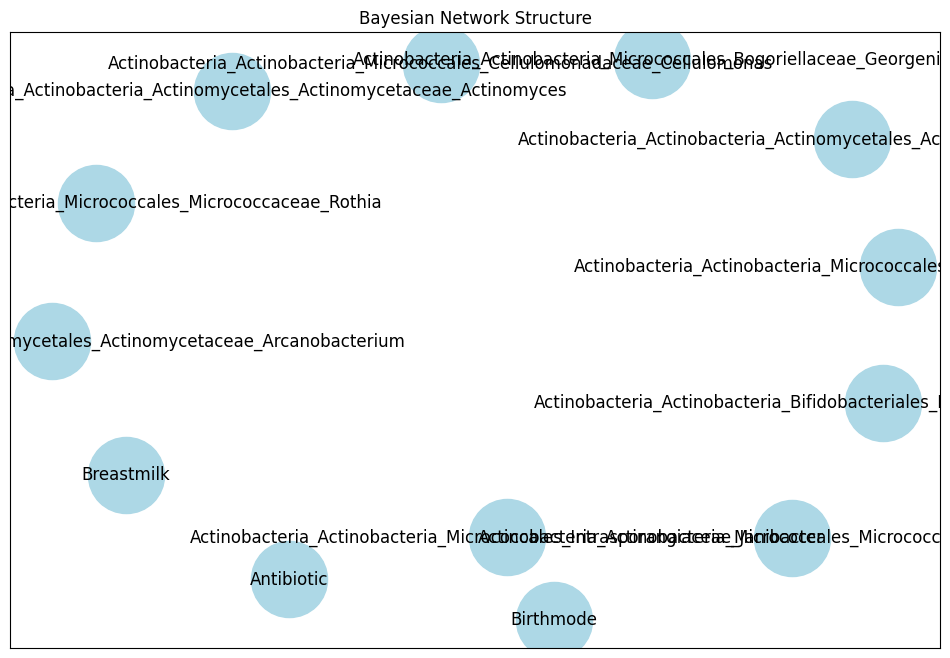

In [ ]:
# Display the learned structure
print("Learned Bayesian Network Structure:")
print(best_model.edges())

# Visualize the Bayesian network
plt.figure(figsize=(12, 8))
nx.draw_networkx(best_model, with_labels=True, node_size=3000, node_color="lightblue")
plt.title("Bayesian Network Structure")
plt.show()

In [ ]:
# Fit the Bayesian network
model = BayesianNetwork(best_model)
model.fit(analysis_data)

# Perform inference using the fitted model
inference = VariableElimination(model)

In [ ]:
# Example queries to determine influence of external factors
# Probability of a specific taxon being high given Birthmode = "Vaginal"
result = inference.query(
    variables=[selected_taxa[0]],
    evidence={"Birthmode": "Vaginal"}
)
print(f"Influence of Birthmode on {selected_taxa[0]}:\n", result)

Influence of Birthmode on Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinomyces:
 +--------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------+
| Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinomyces                       |   phi(Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinomyces) |
+==================================================================================================+===================================================================================+
| Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinomyces(0.0)                  |                                                                            0.2000 |
+--------------------------------------------------------------------------------------------------+---------------------------------------------------------

In [ ]:
# Probability of the same taxon given Breastmilk = "1" (yes)
result = inference.query(
    variables=[selected_taxa[0]],
    evidence={"Breastmilk": "1"}
)
print(f"Influence of Breastmilk on {selected_taxa[0]}:\n", result)

# Probability of the same taxon given Antibiotic = "1" (yes)
result = inference.query(
    variables=[selected_taxa[0]],
    evidence={"Antibiotic": "1"}
)
print(f"Influence of Antibiotic on {selected_taxa[0]}:\n", result)

Influence of Breastmilk on Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinomyces:
 +--------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------+
| Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinomyces                       |   phi(Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinomyces) |
+==================================================================================================+===================================================================================+
| Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinomyces(0.0)                  |                                                                            0.2000 |
+--------------------------------------------------------------------------------------------------+--------------------------------------------------------